## **Customer shopping**

### Contents
1. Load data and check size
2. Drop unused columns
3. Check missing values, duplicates, and dtypes
4. Split by Gender
5. EDA — Item Purchased, Size, Category, Review Rating, Purchase Amount
6. Multivariate — correlation heatmap
7. Feature engineering — dummy variables, scaling, binning
8. Summary

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [46]:
df = pd.read_csv('shopping_trends (1).csv')
df.head()


In [47]:
df.shape


In [48]:
df = df.drop(columns=['Customer ID'])
df.head()


### **Data quality**

Check dtypes, missing values, and duplicate rows before plotting.

In [ ]:
df.info()


In [49]:
df.isnull().sum()


In [ ]:
df.duplicated().sum()


In [ ]:
df.describe()


In [ ]:
male_df = df[df['Gender'] == 'Male'].copy()
female_df = df[df['Gender'] == 'Female'].copy()

male_df.shape, female_df.shape


## **EDA**

### **Item Purchased**

In [50]:
top_item_m = male_df['Item Purchased'].value_counts().reset_index()
top_item_f = female_df['Item Purchased'].value_counts().reset_index()
top_item = df['Item Purchased'].value_counts().reset_index()

print("Top items - All customers")
display(top_item.head(10))

print("Top items - Males")
display(top_item_m.head(10))

print("Top items - Females")
display(top_item_f.head(10))


In [51]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_item.head(10),
    y='Item Purchased',
    x='count',
    hue='Item Purchased',
    dodge=False,
    legend=False
)
plt.title("Top 10 Purchased Items by All Customers")
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()


In [52]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_item_m.head(10),
    y='Item Purchased',
    x='count',
    hue='Item Purchased',
    dodge=False,
    legend=False
)
plt.title("Top 10 Purchased Items by Males")
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()


In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_item_f.head(10),
    y='Item Purchased',
    x='count',
    hue='Item Purchased',
    dodge=False,
    legend=False
)
plt.title("Top 10 Purchased Items by Females")
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()


In [53]:
size_counts = df['Size'].value_counts()
size_counts


In [54]:
size_counts_m = male_df['Size'].value_counts()
size_counts_f = female_df['Size'].value_counts()

print("Male size counts:")
display(size_counts_m)

print("Female size counts:")
display(size_counts_f)


### **Category**

In [55]:
ctg = df['Category'].value_counts().reset_index()
ctg


In [56]:
ctg_m = male_df['Category'].value_counts().reset_index()
ctg_f = female_df['Category'].value_counts().reset_index()

print("Male categories:")
display(ctg_m)

print("Female categories:")
display(ctg_f)


In [57]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=ctg_m,
    x='Category',
    y='count',
    hue='Category',
    dodge=False,
    legend=False
)
plt.title("Preferred Category by Males")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()


In [58]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=ctg_f,
    x='Category',
    y='count',
    hue='Category',
    dodge=False,
    legend=False
)
plt.title("Preferred Category by Females")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()


In [59]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=ctg,
    x='Category',
    y='count',
    hue='Category',
    dodge=False,
    legend=False
)
plt.title("Preferred Category by both Genders")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()


In [60]:
waffle_data_m = dict(male_df['Category'].value_counts())
waffle_data_f = dict(female_df['Category'].value_counts())

waffle_data_m, waffle_data_f


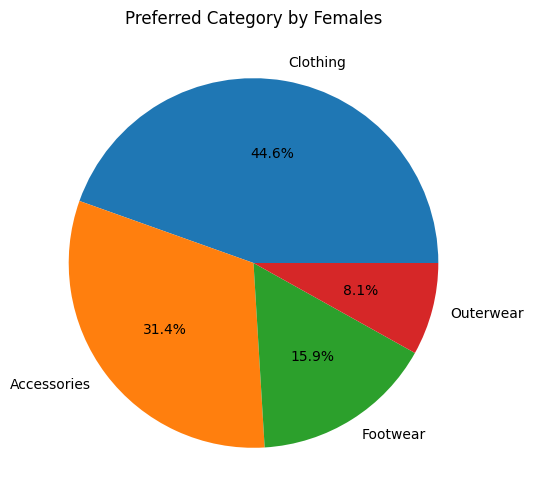

In [ ]:
plt.figure(figsize=(6, 6))
plt.pie(
    waffle_data_f.values(),
    labels=waffle_data_f.keys(),
    autopct='%1.1f%%'
)
plt.title("Preferred Category by Females")
plt.show()


In [62]:
plt.figure(figsize=(6, 6))
plt.pie(
    waffle_data_m.values(),
    labels=waffle_data_m.keys(),
    autopct='%1.1f%%'
)
plt.title("Preferred Category by Males")
plt.show()


### **Review ratings**

In [ ]:
cr_f = female_df[female_df['Category'] == 'Clothing']
avg_cr_f = cr_f['Review Rating'].mean()

avg_cr_f


In [ ]:
cr_m = male_df[male_df['Category'] == 'Clothing']
avg_cr_m = cr_m['Review Rating'].mean()

avg_cr_m


In [ ]:
avg_cr_m, avg_cr_f


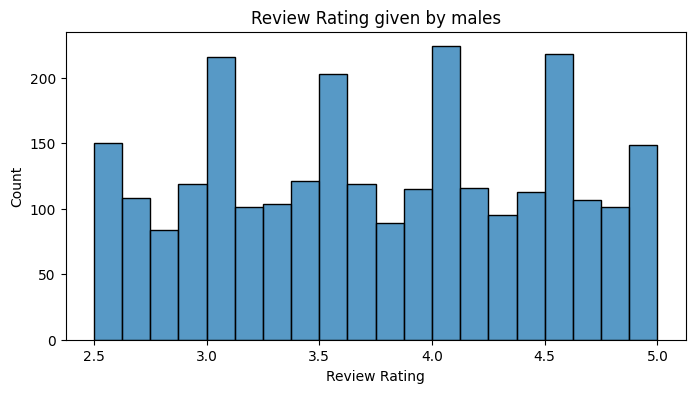

In [73]:
# males
plt.figure(figsize=(8, 4))
sns.histplot(data=male_df, x='Review Rating', bins=20, color='steelblue')
plt.title("Review Rating given by males")
plt.show()

# females
plt.figure(figsize=(8, 4))
sns.histplot(data=female_df, x='Review Rating', bins=20, color='salmon')
plt.title("Review Rating given by females")
plt.show()


In [65]:
cr_m['Review Rating'].value_counts().sort_index()


### **Purchase Amount (USD)**

In [ ]:
m_tpa = male_df['Purchase Amount (USD)'].sum()
f_tpa = female_df['Purchase Amount (USD)'].sum()

m_tpa, f_tpa


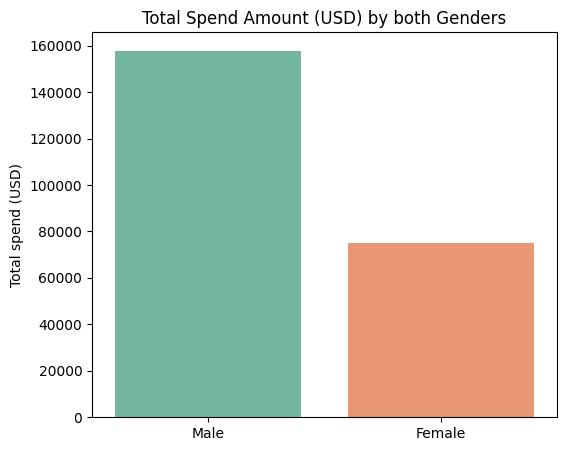

In [ ]:
spend_by_gender = pd.DataFrame({
    'Gender': ['Male', 'Female'],
    'Total Spend (USD)': [m_tpa, f_tpa]
})

plt.figure(figsize=(6, 5))
sns.barplot(
    data=spend_by_gender,
    x='Gender',
    y='Total Spend (USD)',
    hue='Gender',
    dodge=False,
    legend=False
)
plt.title("Total Spend Amount (USD) by both Genders")
plt.ylabel('Total spend (USD)')
plt.show()


In [69]:
cc_f = cr_f
ca_f = female_df[female_df['Category'] == 'Accessories']
cf_f = female_df[female_df['Category'] == 'Footwear']
co_f = female_df[female_df['Category'] == 'Outerwear']

cc_f.shape, ca_f.shape, cf_f.shape, co_f.shape


In [ ]:
cc_m = cr_m
ca_m = male_df[male_df['Category'] == 'Accessories']
cf_m = male_df[male_df['Category'] == 'Footwear']
co_m = male_df[male_df['Category'] == 'Outerwear']

cc_m.shape, ca_m.shape, cf_m.shape, co_m.shape


In [72]:
pcu = dict(df['Promo Code Used'].value_counts())
pcu


### **Relationships (multivariate)**

Numeric columns only: Age, Purchase Amount (USD), Review Rating, Previous Purchases.

In [74]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

corr


### **Feature engineering**

Dummy variables for columns with few levels. Scale numeric columns (keep originals). Bin purchase amount.

In [ ]:
df = pd.get_dummies(
    df,
    columns=['Gender', 'Size', 'Category'],
    dtype=int
)

df.head()


In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

minmax_scaler = MinMaxScaler()
standard_scaler = StandardScaler()

df['Amount_minmax'] = minmax_scaler.fit_transform(
    df[['Purchase Amount (USD)']]
).ravel()

df['Age_standard'] = standard_scaler.fit_transform(
    df[['Age']]
).ravel()

df[['Purchase Amount (USD)', 'Amount_minmax', 'Age', 'Age_standard']].head()


In [ ]:
df['Amount_bin'] = pd.cut(
    df['Purchase Amount (USD)'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)

df['Amount_bin'].value_counts()


### **Summary**

Write 4–5 insights from the plots. These are associations, not causal claims.

Examples to check:
- Which items and categories are most common for males vs females?
- Do males and females spend a similar total amount?
- Is Review Rating similar across genders?
- How often is a promo code used?

### Insights from the data
- **Clothing** is the most common category for both genders: 1,181 male purchases and 556 female purchases.
- The most purchased item differs by gender: **Pants** is highest for males (123), while **Blouse** is highest for females (66).
- Total spending is **$157,890 for males** and **$75,191 for females**. This difference is strongly affected by the unequal number of observations (2,652 males vs. 1,248 females), so it should not be interpreted as males inherently spending more.
- Mean review ratings are very similar: about **3.75 for males** and **3.74 for females**. For Clothing only, the averages are also close (about 3.73 vs. 3.70).
- Promo codes were used in **1,677 of 3,900 purchases (43%)**; 57% of purchases did not use a promo code.
- Correlations among Age, Purchase Amount, Review Rating, and Previous Purchases are all very weak in this dataset.

Caveat: correlation is not causation.
